# unsupervised models

# Clustering Model Training
### K-Means, DBSCAN, HDBSCAN, and GMM clustering models.


## 1. Import Libraries


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import joblib
import os

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except ImportError:
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN not available. Install with: pip install hdbscan")


HDBSCAN not available. Install with: pip install hdbscan


## 2. Load Preprocessed Data


In [2]:
df = pd.read_csv('data/processed/final_preprocessed_clustering.csv')
print(f"Dataset shape: {df.shape}")


Dataset shape: (11306, 216)


## 3. Prepare Features


In [3]:
# Exclude ID and date columns

X = df.drop(['Transaction ID', 'Customer ID', 'Transaction Date'], axis=1)
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")



Features: 213, Samples: 11306


## 4. Find Optimal K


In [7]:
# Test k values from 2 to 8
scores = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    score = silhouette_score(X,kmeans.labels_)
    scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.3f}")

# Find optimal k
optimal_k = range(2, 9)[np.argmax(scores)]
print(f"\nOptimal k = {optimal_k}")


k=2: Silhouette Score = 0.207
k=3: Silhouette Score = 0.171
k=4: Silhouette Score = 0.152
k=5: Silhouette Score = 0.119
k=6: Silhouette Score = 0.104
k=7: Silhouette Score = 0.103
k=8: Silhouette Score = 0.095

Optimal k = 2


## 5. Train Model


In [8]:
# Train K-Means with optimal k
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(X)

# Get cluster labels
cluster_labels = kmeans_model.labels_

print(f"Model trained with k={optimal_k}")
print(f"Silhouette Score: {silhouette_score(X, cluster_labels):.3f}")
print(f"\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())


Model trained with k=2
Silhouette Score: 0.207

Cluster distribution:
0    7049
1    4257
Name: count, dtype: int64


## 6. Save Results


In [23]:
# Create directories
os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(kmeans_model, 'models/kmeans_model.pkl')
print("Model saved: models/kmeans_model.pkl")



Model saved: models/kmeans_model.pkl


In [24]:
# Save cluster labels
pd.DataFrame({'Cluster': cluster_labels}).to_csv('data/processed/kmeans_cluster_labels.csv', index=False)
print("Labels saved: data/processed/kmeans_cluster_labels.csv")

Labels saved: data/processed/kmeans_cluster_labels.csv


In [25]:
# Save data with clusters
df['Cluster'] = cluster_labels
df.to_csv('data/processed/clustered_data.csv', index=False)
print("Clustered data saved: data/processed/clustered_data.csv")


Clustered data saved: data/processed/clustered_data.csv


## DBSCAN Clustering


### 7. Find Optimal Parameters


### Test different eps values (DBSCAN parameter)


In [11]:
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples = 5

best_eps = None
best_score = -1
best_labels = None

print("Testing different eps values...")
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    
    # Count clusters (excluding noise points labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Calculate silhouette score (only if we have at least 2 clusters and not all noise)
    if n_clusters >= 2 and n_noise < len(labels) * 0.5:
        score = silhouette_score(X, labels)
        print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={score:.3f}")
        
        if score > best_score:
            best_score = score
            best_eps = eps
            best_labels = labels
    else:
        print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise} (too many noise points)")

if best_eps is not None:
    print(f"\nOptimal eps = {best_eps}")
    optimal_eps = best_eps
else:
    # Default if no good parameters found
    optimal_eps = 1.5
    print(f"\nUsing default eps = {optimal_eps}")



Testing different eps values...
eps=0.5: Clusters=296, Noise=9383 (too many noise points)
eps=1.0: Clusters=354, Noise=2669, Silhouette=-0.062
eps=1.5: Clusters=1, Noise=3 (too many noise points)
eps=2.0: Clusters=1, Noise=0 (too many noise points)
eps=2.5: Clusters=1, Noise=0 (too many noise points)

Optimal eps = 1.0


### 8. Train DBSCAN Model


In [12]:
# Train DBSCAN with optimal parameters
dbscan_model = DBSCAN(eps=optimal_eps, min_samples=min_samples)
dbscan_labels = dbscan_model.fit_predict(X)

# Count clusters and noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Model trained")
print(f"eps = {optimal_eps}, min_samples = {min_samples}")
print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters >= 2:
    score = silhouette_score(X, dbscan_labels)
    print(f"Silhouette Score: {score:.3f}")

print(f"\nCluster distribution:")
cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
print(cluster_counts)


DBSCAN Model trained
eps = 1.0, min_samples = 5
Number of clusters: 354
Noise points: 2669 (23.6%)
Silhouette Score: -0.062

Cluster distribution:
-1      2669
 0        50
 1        86
 2        65
 3        33
        ... 
 349       2
 350       5
 351       5
 352       4
 353       5
Name: count, Length: 355, dtype: int64


### 9. Save DBSCAN Results


In [20]:
# Save DBSCAN model
joblib.dump(dbscan_model, 'models/dbscan_model.pkl')
print("DBSCAN model saved: models/dbscan_model.pkl")



DBSCAN model saved: models/dbscan_model.pkl


In [21]:
# Save DBSCAN cluster labels
pd.DataFrame({'Cluster': dbscan_labels}).to_csv('data/processed/dbscan_cluster_labels.csv', index=False)
print("DBSCAN labels saved: data/processed/dbscan_cluster_labels.csv")



DBSCAN labels saved: data/processed/dbscan_cluster_labels.csv


In [22]:
# Save data with DBSCAN clusters
df_dbscan = df.copy()
df_dbscan['DBSCAN_Cluster'] = dbscan_labels
df_dbscan.to_csv('data/processed/dbscan_clustered_data.csv', index=False)
print("DBSCAN clustered data saved: data/processed/dbscan_clustered_data.csv")



DBSCAN clustered data saved: data/processed/dbscan_clustered_data.csv


### HDBSCAN Clustering (Improved Alternative to DBSCAN)
### HDBSCAN advantages:
### - Handles varying density clusters better
### - Works better with high-dimensional data
### - More robust parameter selection


### 9. Find Optimal HDBSCAN Parameters


In [39]:
if HDBSCAN_AVAILABLE:
    # Test different min_cluster_size values
    min_cluster_sizes = [5, 10, 15, 20]
    min_samples = 10  # Fixed value
    
    scores = []
    for min_cluster_size in min_cluster_sizes:
        hdbscan_test = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, 
                                       min_samples=min_samples,
                                       metric='euclidean')
        labels = hdbscan_test.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters >= 2:
            score = silhouette_score(X, labels)
            scores.append(score)
            print(f"min_cluster_size={min_cluster_size}: Clusters={n_clusters}, "
                  f"Noise={n_noise} ({n_noise/len(labels)*100:.1f}%), Silhouette={score:.3f}")
        else:
            scores.append(-1)
            print(f"min_cluster_size={min_cluster_size}: Clusters={n_clusters} (too few clusters)")
    
    # Find optimal min_cluster_size
    optimal_min_cluster_size = min_cluster_sizes[np.argmax(scores)]
    optimal_min_samples = min_samples
    print(f"\nOptimal min_cluster_size = {optimal_min_cluster_size}")
else:
    # Use Agglomerative Clustering - test different n_clusters
    print("HDBSCAN not available. Testing Agglomerative Clustering...")
    scores = []
    for n in range(2, 9):
        agg = AgglomerativeClustering(n_clusters=n)
        labels = agg.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
        print(f"n_clusters={n}: Silhouette Score = {score:.3f}")
    
    optimal_n_clusters = range(2, 9)[np.argmax(scores)]
    print(f"\nOptimal n_clusters = {optimal_n_clusters}")
    optimal_min_cluster_size = None
    optimal_min_samples = None

HDBSCAN not available. Testing Agglomerative Clustering...
n_clusters=2: Silhouette Score = 0.175
n_clusters=3: Silhouette Score = 0.134
n_clusters=4: Silhouette Score = 0.106
n_clusters=5: Silhouette Score = 0.074
n_clusters=6: Silhouette Score = 0.065
n_clusters=7: Silhouette Score = 0.057
n_clusters=8: Silhouette Score = 0.053

Optimal n_clusters = 2


### 10. Train HDBSCAN Model


In [40]:
if HDBSCAN_AVAILABLE:
    # Train HDBSCAN with optimal parameters
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=optimal_min_cluster_size, 
                                     min_samples=optimal_min_samples,
                                     metric='euclidean')
    hdbscan_labels = hdbscan_model.fit_predict(X)
    
    # Count clusters and noise
    n_clusters_hdbscan = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
    n_noise_hdbscan = list(hdbscan_labels).count(-1)
    
    print(f"HDBSCAN Model trained")
    print(f"min_cluster_size = {optimal_min_cluster_size}, min_samples = {optimal_min_samples}")
    print(f"Silhouette Score: {silhouette_score(X, hdbscan_labels):.3f}")
    print(f"\nCluster distribution:")
    print(pd.Series(hdbscan_labels).value_counts().sort_index())
else:
    # Train Agglomerative Clustering with optimal n_clusters
    hdbscan_model = AgglomerativeClustering(n_clusters=optimal_n_clusters)
    hdbscan_labels = hdbscan_model.fit_predict(X)
    
    n_clusters_hdbscan = optimal_n_clusters
    n_noise_hdbscan = 0
    
    print(f"Agglomerative Clustering Model trained")
    print(f"n_clusters = {optimal_n_clusters}")
    print(f"Silhouette Score: {silhouette_score(X, hdbscan_labels):.3f}")
    print(f"\nCluster distribution:")
    print(pd.Series(hdbscan_labels).value_counts().sort_index())



Agglomerative Clustering Model trained
n_clusters = 2
Silhouette Score: 0.175

Cluster distribution:
0    6779
1    4527
Name: count, dtype: int64


### 11. Save HDBSCAN Results


In [47]:
# Save HDBSCAN model
model_name = 'hdbscan_model.pkl' if HDBSCAN_AVAILABLE else 'agglomerative_model.pkl'
joblib.dump(hdbscan_model, f'models/{model_name}')
print(f"Model saved: models/{model_name}")


Model saved: models/agglomerative_model.pkl


In [48]:
# Save cluster labels
label_file = 'hdbscan_cluster_labels.csv' if HDBSCAN_AVAILABLE else 'agglomerative_cluster_labels.csv'
pd.DataFrame({'Cluster': hdbscan_labels}).to_csv(f'data/processed/{label_file}', index=False)
print(f"Labels saved: data/processed/{label_file}")


Labels saved: data/processed/agglomerative_cluster_labels.csv


In [49]:
# Save data with clusters
df_hdbscan = df.copy()
cluster_col = 'HDBSCAN_Cluster' if HDBSCAN_AVAILABLE else 'Agglomerative_Cluster'
df_hdbscan[cluster_col] = hdbscan_labels
data_file = 'hdbscan_clustered_data.csv' if HDBSCAN_AVAILABLE else 'agglomerative_clustered_data.csv'
df_hdbscan.to_csv(f'data/processed/{data_file}', index=False)
print(f"Clustered data saved: data/processed/{data_file}")


Clustered data saved: data/processed/agglomerative_clustered_data.csv


## Gaussian Mixture Model (GMM) Clustering


### 10. Find Optimal Number of Components


In [41]:
# Test different numbers of components
n_components_range = range(2, 9)
gmm_scores = []
aic_scores = []
bic_scores = []

print("Testing different numbers of components...")
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    gmm.fit(X)
    labels = gmm.predict(X)
    
    # Calculate metrics
    score = silhouette_score(X, labels)
    aic = gmm.aic(X)
    bic = gmm.bic(X)
    
    gmm_scores.append(score)
    aic_scores.append(aic)
    bic_scores.append(bic)
    
    print(f"n_components={n}: Silhouette={score:.3f}, AIC={aic:.2f}, BIC={bic:.2f}")

# Find optimal number of components (highest silhouette score)
optimal_n_components = n_components_range[np.argmax(gmm_scores)]
print(f"\nOptimal n_components = {optimal_n_components}")


Testing different numbers of components...
n_components=2: Silhouette=0.154, AIC=-15920460.74, BIC=-15583072.66
n_components=3: Silhouette=0.084, AIC=-19064971.30, BIC=-18558885.50
n_components=4: Silhouette=0.017, AIC=-21605748.41, BIC=-20930964.91
n_components=5: Silhouette=0.010, AIC=-22419270.81, BIC=-21575789.60
n_components=6: Silhouette=0.006, AIC=-23412719.09, BIC=-22400540.17
n_components=7: Silhouette=0.004, AIC=-22717086.76, BIC=-21536210.13
n_components=8: Silhouette=0.007, AIC=-24192316.19, BIC=-22842741.85

Optimal n_components = 2


### 11. Train GMM Model


In [42]:
# Train GMM with optimal number of components
gmm_model = GaussianMixture(n_components=optimal_n_components, random_state=42, n_init=10)
gmm_model.fit(X)

# Get cluster labels
gmm_labels = gmm_model.predict(X)

print(f"GMM Model trained")
print(f"Number of components: {optimal_n_components}")
print(f"Silhouette Score: {silhouette_score(X, gmm_labels):.3f}")
print(f"AIC: {gmm_model.aic(X):.2f}")
print(f"BIC: {gmm_model.bic(X):.2f}")
print(f"\nCluster distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())


GMM Model trained
Number of components: 2
Silhouette Score: 0.154
AIC: -15920460.74
BIC: -15583072.66

Cluster distribution:
0    4178
1    7128
Name: count, dtype: int64


### 12. Save GMM Results


In [43]:
# Save GMM model
joblib.dump(gmm_model, 'models/gmm_model.pkl')
print("GMM model saved: models/gmm_model.pkl")





GMM model saved: models/gmm_model.pkl


In [44]:
# Save GMM cluster labels
pd.DataFrame({'Cluster': gmm_labels}).to_csv('data/processed/gmm_cluster_labels.csv', index=False)
print("GMM labels saved: data/processed/gmm_cluster_labels.csv")



GMM labels saved: data/processed/gmm_cluster_labels.csv


In [45]:
# Save data with GMM clusters
df_gmm = df.copy()
df_gmm['GMM_Cluster'] = gmm_labels
df_gmm.to_csv('data/processed/gmm_clustered_data.csv', index=False)
print("GMM clustered data saved: data/processed/gmm_clustered_data.csv")

GMM clustered data saved: data/processed/gmm_clustered_data.csv


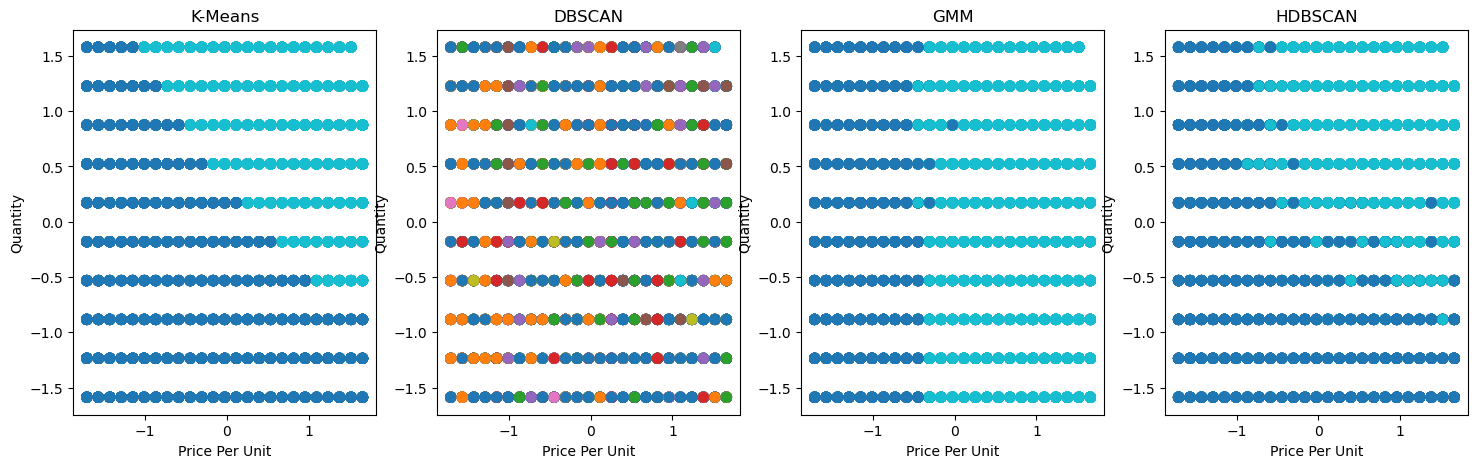

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18,5))

models = [('K-Means', cluster_labels),
          ('DBSCAN', dbscan_labels),
          ('GMM', gmm_labels),
          ('HDBSCAN', hdbscan_labels)]

for ax, (name, labels) in zip(axes, models):
    scatter = ax.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap='tab10', s=50)
    ax.set_title(name)
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])

plt.show()


# Evaluation K-Means


In [52]:
silhouette_kmeans = silhouette_score(X, cluster_labels)
print(f"K-Means Silhouette Score: {silhouette_kmeans:.3f}")



K-Means Silhouette Score: 0.207


# Evaluation DBSCAN


In [53]:
if len(set(dbscan_labels)) > 1 :
    silhouette_dbscan = silhouette_score(X, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {silhouette_dbscan:.3f}")

DBSCAN Silhouette Score: -0.062
